# Voice PCA Pipeline - Guided Setup
**End-to-end ML pipeline for voice/acoustic data that has already been PCA-transformed.**

**Input**: A CSV where all feature columns are PCA components (PC1, PC2, ...) and are expected to be numeric.

**This guided version improves three areas while keeping the same goal:**
1. Step 3.5 combines manual column drop and target-column selection.
2. Cross-validation and tuning fail fast with clearer diagnostics.
3. Final evaluation records richer metrics for model comparison.

**Pipeline Steps:**
1. Imports & Hardware Detection
2. Configuration
3. Data Loading
4. Column Overview
5. Manual Setup (Drop Columns + Select Target)
6. Data Profiling & Quality Audit
7. Target Validation
8. Auto-Clean
9. Target Analysis & Train/Test Split
10. Outlier Smoothing
11. Loose Feature Selection
12. Feature Scaling
13. Model Shortlisting
14. Cross-Validated Training & Ranking
15. Top-K Selection
16. Hyperparameter Tuning
17. Final Evaluation
18. Save Artifacts

In [ ]:
# ============================================================
# STEP 0: IMPORTS & HARDWARE DETECTION
# ============================================================

import os
import json
import warnings
import datetime
import platform
import multiprocessing

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import joblib
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.base import clone
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

# ---- Hardware Detection ----
print('=' * 60)
print('HARDWARE DETECTION')
print('=' * 60)

N_CORES = multiprocessing.cpu_count()
N_JOBS = max(1, N_CORES - 1)  # leave 1 core free for OS
print(f'  CPU cores detected : {N_CORES}')
print(f'  n_jobs for parallel: {N_JOBS}')
print(f'  Platform           : {platform.system()} {platform.machine()}')

# GPU detection
GPU_AVAILABLE = False
GPU_TYPE = 'none'

# CUDA (NVIDIA)
try:
    import torch
    if torch.cuda.is_available():
        GPU_AVAILABLE = True
        GPU_TYPE = 'cuda'
        print(f'  GPU (CUDA)         : {torch.cuda.get_device_name(0)}')
    else:
        print('  GPU (CUDA)         : Not available')
except ImportError:
    print('  GPU (CUDA)         : torch not installed, checking via subprocess...')
    try:
        import subprocess
        result = subprocess.run(['nvidia-smi'], capture_output=True, text=True, timeout=5)
        if result.returncode == 0:
            GPU_AVAILABLE = True
            GPU_TYPE = 'cuda'
            print('  GPU (CUDA)         : NVIDIA GPU detected via nvidia-smi')
        else:
            print('  GPU (CUDA)         : Not available')
    except Exception:
        print('  GPU (CUDA)         : Not available')

# Apple MPS
if not GPU_AVAILABLE:
    try:
        import torch
        if torch.backends.mps.is_available():
            GPU_AVAILABLE = True
            GPU_TYPE = 'mps'
            print('  GPU (MPS/Apple)    : Available')
    except Exception:
        pass

if not GPU_AVAILABLE:
    print('  GPU                : None detected -- will use CPU with max threads')

# XGBoost device string
XGB_DEVICE = 'cuda' if GPU_TYPE == 'cuda' else 'cpu'
print(f'  XGBoost device     : {XGB_DEVICE}')
print('=' * 60)
print('Step 0 complete: imports loaded, hardware profiled.')

HARDWARE DETECTION
  CPU cores detected : 8
  n_jobs for parallel: 7
  Platform           : Windows AMD64
  GPU (CUDA)         : NVIDIA GeForce GTX 1650 Ti
  XGBoost device     : cuda
Step 0 complete: imports loaded, hardware profiled.


In [21]:
# ============================================================
# STEP 1: CONFIGURATION
# ============================================================

# ---- USER SETTINGS -- edit these before running ----
CSV_FILE_PATH = r'data\features_pca_dataset.csv'   # <-- set your PCA CSV path here
RANDOM_SEED   = 42
TEST_SIZE     = 0.20    # 80/20 split
CV_FOLDS      = 5
TOP_K_MODELS  = 2       # how many models go to Optuna tuning
OPTUNA_TRIALS = 30      # increase for 50K+ row datasets
OPTUNA_TIMEOUT = 300    # seconds per model (5 min)
OUTPUT_DIR    = 'voice_ml_pipeline_output'

# --- Tunable thresholds used by later steps ---
OUTLIER_THRESHOLD_PCT   = 0.3     # Step 8: treat col if >0.3% values are outliers
FEATURE_DROP_BOTTOM_PCT = 0.02    # Step 9: drop if bottom 2% by BOTH MI and RF
LEAKAGE_CORR_THRESHOLD  = 0.999   # Step 6: drop if |corr w/ target| >= this
NEAR_ZERO_STD_THRESHOLD = 1e-6    # Step 9: near-zero variance threshold

# --- Model shortlisting thresholds (Step 11) ---
XGB_MAX_SAMPLES_CPU = 100_000
LOGREG_MAX_SAMPLES  = 50_000
LOGREG_MAX_FEATURES = 100
SVM_MAX_SAMPLES     = 20_000
SVM_MAX_FEATURES    = 50
KNN_MAX_SAMPLES     = 50_000
# ---------------------------------------------------

np.random.seed(RANDOM_SEED)

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Global state -- every step writes here, saved to disk at the end
PIPELINE_STATE = {
    'config': {
        'csv_file': CSV_FILE_PATH,
        'random_seed': RANDOM_SEED,
        'test_size': TEST_SIZE,
        'cv_folds': CV_FOLDS,
        'top_k_models': TOP_K_MODELS,
        'optuna_trials': OPTUNA_TRIALS,
        'optuna_timeout': OPTUNA_TIMEOUT,
        'outlier_threshold_pct'   : OUTLIER_THRESHOLD_PCT,
        'feature_drop_bottom_pct' : FEATURE_DROP_BOTTOM_PCT,
        'leakage_corr_threshold'  : LEAKAGE_CORR_THRESHOLD,
        'near_zero_std_threshold' : NEAR_ZERO_STD_THRESHOLD,
        'hardware': {
            'n_cores': N_CORES,
            'n_jobs': N_JOBS,
            'gpu_available': GPU_AVAILABLE,
            'gpu_type': GPU_TYPE
        }
    }
}

print('Step 1 complete: configuration set.')
print(f'  CSV path    : {CSV_FILE_PATH}')
print(f'  Output dir  : {OUTPUT_DIR}')
print(f'  Optuna      : {OPTUNA_TRIALS} trials / {OPTUNA_TIMEOUT}s timeout per model')

Step 1 complete: configuration set.
  CSV path    : data\features_pca_dataset.csv
  Output dir  : voice_ml_pipeline_output
  Optuna      : 30 trials / 300s timeout per model


In [22]:
# ============================================================
# STEP 2: DATA LOADING
# ============================================================
# INPUT  : CSV file path from config
# OUTPUT : raw DataFrame `df`, shape logged
# ============================================================

try:
    print('=' * 60)
    print('STEP 2: DATA LOADING')
    print('=' * 60)

    if not os.path.exists(CSV_FILE_PATH):
        raise FileNotFoundError(
            f'[STEP 2 ERROR] CSV file not found at: {CSV_FILE_PATH}\n'
            f'  Please update CSV_FILE_PATH in Step 1 and re-run.'
        )

    df = pd.read_csv(CSV_FILE_PATH)

    print(f'  [INPUT]  File       : {CSV_FILE_PATH}')
    print(f'  [OUTPUT] Shape      : {df.shape[0]:,} rows x {df.shape[1]} columns')
    print(f'           Memory     : {df.memory_usage(deep=True).sum() / 1e6:.2f} MB')
    print()

    # dtype breakdown
    dtype_counts = df.dtypes.value_counts()
    print('  Column dtype breakdown:')
    for dtype, count in dtype_counts.items():
        print(f'    {str(dtype):<12} : {count} columns')

    print()
    print('  First 3 rows preview:')
    display(df.head(3))

    PIPELINE_STATE['data_loading'] = {
        'n_rows': int(df.shape[0]),
        'n_cols': int(df.shape[1]),
        'memory_mb': round(df.memory_usage(deep=True).sum() / 1e6, 2),
        'columns': list(df.columns)
    }

    print('\nStep 2 complete: data loaded successfully.')

except FileNotFoundError as e:
    print(str(e))
    raise
except Exception as e:
    print(f'[STEP 2 ERROR] Unexpected error during data loading: {type(e).__name__}: {e}')
    raise

STEP 2: DATA LOADING
  [INPUT]  File       : data\features_pca_dataset.csv
  [OUTPUT] Shape      : 4,800 rows x 15 columns
           Memory     : 0.81 MB

  Column dtype breakdown:
    float64      : 14 columns
    object       : 1 columns

  First 3 rows preview:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,label
0,5.143221,-1.379200,4.160624,0.923527,1.633539,-0.016542,0.814874,-0.126754,0.856313,-0.762276,0.759660,0.200647,-0.888052,0.398277,Normal
1,1.679540,-4.118910,5.460237,1.303518,2.878897,-0.662957,-0.544075,0.319763,-0.506975,-1.167155,-0.235471,-0.060919,-0.377416,0.267016,Normal
2,4.197026,0.841204,8.430499,2.432170,2.850291,-0.022944,-1.176730,-0.077676,0.354037,-0.269376,0.308550,-0.318504,0.390015,1.089445,Normal



Step 2 complete: data loaded successfully.


In [23]:
# ============================================================
# STEP 3: COLUMN OVERVIEW
# ============================================================
# INPUT  : raw df from Step 2
# OUTPUT : printed column list -- no data changes, review only
# ============================================================

try:
    print('=' * 60)
    print('STEP 3: COLUMN OVERVIEW')
    print('=' * 60)
    print(f'  Total columns: {len(df.columns)}')
    print()

    # Print in groups of 5 for readability
    cols = list(df.columns)
    for i in range(0, len(cols), 5):
        group = cols[i:i+5]
        print('  ' + '  |  '.join(f'{j+i:>4}. {c}' for j, c in enumerate(group)))

    print()

    # Flag any non-PC named columns so user is aware
    pc_cols = [c for c in cols if str(c).upper().startswith('PC') and str(c)[2:].isdigit()]
    other_cols = [c for c in cols if c not in pc_cols]

    print(f'  PCA component columns (PC1, PC2...): {len(pc_cols)}')
    print(f'  Other columns (target, index, etc.): {len(other_cols)}')
    if other_cols:
        print(f'  Other column names: {other_cols}')
        print('  --> Review these -- one should be your target, others may need dropping.')

    PIPELINE_STATE['column_overview'] = {
        'total_columns': len(cols),
        'pc_columns_count': len(pc_cols),
        'other_columns': other_cols
    }

    print('\nStep 3 complete: review columns above. '
          'Drop any unwanted ones in Step 3.5, then set TARGET_COLUMN in Step 5.')

except Exception as e:
    print(f'[STEP 3 ERROR] {type(e).__name__}: {e}')
    raise

STEP 3: COLUMN OVERVIEW
  Total columns: 15

     0. PC1  |     1. PC2  |     2. PC3  |     3. PC4  |     4. PC5
     5. PC6  |     6. PC7  |     7. PC8  |     8. PC9  |     9. PC10
    10. PC11  |    11. PC12  |    12. PC13  |    13. PC14  |    14. label

  PCA component columns (PC1, PC2...): 14
  Other columns (target, index, etc.): 1
  Other column names: ['label']
  --> Review these -- one should be your target, others may need dropping.

Step 3 complete: review columns above. Drop any unwanted ones in Step 3.5, then set TARGET_COLUMN in Step 5.


In [24]:
# ============================================================
# STEP 3.5: MANUAL SETUP (DROP COLUMNS + TARGET COLUMN)
# ============================================================
# USER ACTION : After reviewing the column list in Step 3,
#               set both the columns to drop and the target column here.
# INPUT  : df from Step 2
# OUTPUT : df with unwanted columns removed, TARGET_COLUMN selected
#
# Examples of columns to drop manually:
#   - Index/row-ID columns  (e.g. 'Unnamed: 0', 'row_id')
#   - Redundant metadata columns that came with the export
#   - Any column you know is not a feature or target
# ============================================================

# ---- SET THESE BEFORE RUNNING ----
MANUAL_DROP_COLS = []
TARGET_COLUMN = 'label'   # <-- replace with your actual target column name
# Example: MANUAL_DROP_COLS = ['Unnamed: 0', 'speaker_id', 'file_name']
# ----------------------------------

try:
    print('=' * 60)
    print('STEP 3.5: MANUAL SETUP (DROP COLUMNS + TARGET COLUMN)')
    print('=' * 60)
    print(f'  [INPUT]  Shape          : {df.shape[0]:,} rows x {df.shape[1]} cols')
    print(f'           Cols to drop   : {MANUAL_DROP_COLS if MANUAL_DROP_COLS else "none"}')
    print(f'           Target column  : {TARGET_COLUMN!r}')
    print()

    if TARGET_COLUMN not in df.columns:
        raise ValueError(
            f'[STEP 3.5 ERROR] Target column {TARGET_COLUMN!r} not found in dataframe.\n'
            f'  Check the column list from Step 3 and update TARGET_COLUMN.'
        )

    if TARGET_COLUMN in MANUAL_DROP_COLS:
        raise ValueError(
            f'[STEP 3.5 ERROR] {TARGET_COLUMN!r} is the target column and cannot be dropped.\n'
            f'  Remove it from MANUAL_DROP_COLS.'
        )

    missing = [c for c in MANUAL_DROP_COLS if c not in df.columns]
    if missing:
        raise ValueError(
            f'[STEP 3.5 ERROR] Column(s) not found in dataframe: {missing}\n'
            f'  Check spelling. Available columns: {list(df.columns)}'
        )

    cols_before = df.shape[1]
    if MANUAL_DROP_COLS:
        df = df.drop(columns=MANUAL_DROP_COLS)
        print(f'  Dropped {len(MANUAL_DROP_COLS)} column(s):')
        for col_name in MANUAL_DROP_COLS:
            print(f'    - {col_name}')
    else:
        print('  Nothing specified in MANUAL_DROP_COLS -- skipping drop.')

    cols_after = df.shape[1]
    print(f'  Column count       : {cols_before} --> {cols_after}')

    if TARGET_COLUMN not in df.columns:
        raise ValueError(
            f'[STEP 3.5 ERROR] Target column {TARGET_COLUMN!r} is missing after manual drop.'
        )

    target_preview = df[TARGET_COLUMN]
    print()
    print(f'  [TARGET] Column confirmed : {TARGET_COLUMN!r}')
    print(f'           Dtype            : {target_preview.dtype}')
    print(f'           Null count       : {target_preview.isnull().sum()}')
    print(f'           Unique values    : {target_preview.nunique()}')
    print()
    print(f'  [OUTPUT] Shape          : {df.shape[0]:,} rows x {df.shape[1]} cols')
    print('  Proceed to Step 4 for profiling, then Step 5 for target validation.')

    PIPELINE_STATE['manual_setup'] = {
        'target_column': TARGET_COLUMN,
        'cols_requested': MANUAL_DROP_COLS,
        'n_dropped': len(MANUAL_DROP_COLS),
        'shape_after': list(df.shape)
    }

    print('\nStep 3.5 complete.')

except ValueError as e:
    print(str(e))
    raise
except Exception as e:
    print(f'[STEP 3.5 ERROR] {type(e).__name__}: {e}')
    raise


STEP 3.5: MANUAL SETUP (DROP COLUMNS + TARGET COLUMN)
  [INPUT]  Shape          : 4,800 rows x 15 cols
           Cols to drop   : none
           Target column  : 'label'

  Nothing specified in MANUAL_DROP_COLS -- skipping drop.
  Column count       : 15 --> 15

  [TARGET] Column confirmed : 'label'
           Dtype            : object
           Null count       : 0
           Unique values    : 6

  [OUTPUT] Shape          : 4,800 rows x 15 cols
  Proceed to Step 4 for profiling, then Step 5 for target validation.

Step 3.5 complete.


In [25]:
# ============================================================
# STEP 4: DATA PROFILING & QUALITY AUDIT
# ============================================================
# INPUT  : df (all columns, target not yet selected)
# OUTPUT : COLS_TO_DROP list (populated, not yet applied)
#          Data quality report printed
# NOTE   : TARGET_COLUMN is not defined yet (set in Step 5).
#          Profiling runs on ALL columns. Leakage check is
#          deferred to Step 6 (auto-clean) once target is known.
# ============================================================

try:
    print('=' * 60)
    print('STEP 4: DATA PROFILING & QUALITY AUDIT')
    print('=' * 60)
    print(f'  [INPUT]  Shape : {df.shape[0]:,} rows x {df.shape[1]} cols')
    print(f'           Total columns (target not separated yet): {df.shape[1]}')
    print()

    COLS_TO_DROP = []

    # --- 1. Null values ---
    null_counts = df.isnull().sum()
    null_cols   = null_counts[null_counts > 0]
    null_pct_total = df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100
    print(f'  [Nulls] Columns with nulls : {len(null_cols)} / {df.shape[1]}')
    print(f'          Overall null %      : {null_pct_total:.3f}%')
    if len(null_cols) > 0:
        print('          Top null columns    :')
        for col, cnt in null_cols.sort_values(ascending=False).head(10).items():
            pct = cnt / len(df) * 100
            print(f'            {col:<20}: {cnt:>6,} ({pct:.1f}%)')
            if pct > 80:
                COLS_TO_DROP.append(col)
                print('              --> FLAGGED FOR DROP (>80% null)')
    print()

    # --- 2. Duplicate rows ---
    dup_count = df.duplicated().sum()
    print(f'  [Duplicates] Exact duplicate rows: {dup_count:,} ({dup_count/len(df)*100:.2f}%)')
    print()

    # --- 3. Constant columns (zero variance) ---
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    const_cols   = [c for c in numeric_cols if df[c].nunique() <= 1]
    print(f'  [Constant cols] Columns with 0 or 1 unique value: {len(const_cols)}')
    if const_cols:
        print(f'    Columns: {const_cols}')
        print('    --> FLAGGED FOR DROP (zero variance)')
        COLS_TO_DROP.extend(const_cols)
    print()

    # --- 4. Non-numeric columns ---
    non_numeric = [c for c in df.columns if not pd.api.types.is_numeric_dtype(df[c])]
    print(f'  [Non-numeric] Non-numeric columns: {len(non_numeric)}')
    if non_numeric:
        print(f'    Columns: {non_numeric}')
        print('    NOTE: One of these is likely your target column -- do NOT flag it here.')
        print('    Unexpected non-numeric feature columns will be flagged after target is set.')
    print()

    # --- 5. Near-zero variance (numeric only, not constant) ---
    low_var_cols = [c for c in numeric_cols
                    if c not in const_cols and df[c].std() < 1e-4]
    print(f'  [Low variance] Columns with std < 1e-4 (not constant): {len(low_var_cols)}')
    if low_var_cols:
        print(f'    Columns: {low_var_cols}')
        print('    --> FLAGGED FOR DROP (near-zero variance)')
        COLS_TO_DROP.extend(low_var_cols)
    print()

    # Deduplicate drop list
    COLS_TO_DROP = list(set(COLS_TO_DROP))

    print(f'  [SUMMARY] Columns auto-flagged for removal : {len(COLS_TO_DROP)}')
    if COLS_TO_DROP:
        for c in COLS_TO_DROP:
            print(f'    - {c}')
    print(f'  NOTE: Leakage check runs in Step 6 (after target is selected in Step 5).')
    print()
    print(f'  [OUTPUT] Shape      : {df.shape[0]:,} rows x {df.shape[1]} cols (unchanged)')
    print(f'           Drop list  : {len(COLS_TO_DROP)} columns queued for removal in Step 6')

    PIPELINE_STATE['profiling'] = {
        'n_cols_total'     : int(df.shape[1]),
        'null_pct_total'   : round(null_pct_total, 3),
        'duplicate_rows'   : int(dup_count),
        'constant_cols'    : const_cols,
        'low_var_cols'     : low_var_cols,
        'non_numeric_cols' : non_numeric,
        'cols_flagged_for_drop': COLS_TO_DROP
    }

    print('\nStep 4 complete: profiling done. Set TARGET_COLUMN in Step 5.')

except Exception as e:
    print(f'[STEP 4 ERROR] {type(e).__name__}: {e}')
    raise


STEP 4: DATA PROFILING & QUALITY AUDIT
  [INPUT]  Shape : 4,800 rows x 15 cols
           Total columns (target not separated yet): 15

  [Nulls] Columns with nulls : 0 / 15
          Overall null %      : 0.000%

  [Duplicates] Exact duplicate rows: 38 (0.79%)

  [Constant cols] Columns with 0 or 1 unique value: 0

  [Non-numeric] Non-numeric columns: 1
    Columns: ['label']
    NOTE: One of these is likely your target column -- do NOT flag it here.
    Unexpected non-numeric feature columns will be flagged after target is set.

  [Low variance] Columns with std < 1e-4 (not constant): 0

  [SUMMARY] Columns auto-flagged for removal : 0
  NOTE: Leakage check runs in Step 6 (after target is selected in Step 5).

  [OUTPUT] Shape      : 4,800 rows x 15 cols (unchanged)
           Drop list  : 0 columns queued for removal in Step 6

Step 4 complete: profiling done. Set TARGET_COLUMN in Step 5.


In [26]:
# ============================================================
# COLUMN REFERENCE (OPTIONAL CHECK)
# ============================================================
print("=" * 60)
print("All columns currently in dataframe:")
print("=" * 60)
for i, col in enumerate(df.columns):
    print(f"  {i:>3}.  {col}")
print("=" * 60)
print(f"TARGET_COLUMN from Step 3.5: {TARGET_COLUMN!r}")
print("If this is wrong, update Step 3.5 and re-run from there.")


All columns currently in dataframe:
    0.  PC1
    1.  PC2
    2.  PC3
    3.  PC4
    4.  PC5
    5.  PC6
    6.  PC7
    7.  PC8
    8.  PC9
    9.  PC10
   10.  PC11
   11.  PC12
   12.  PC13
   13.  PC14
   14.  label
TARGET_COLUMN from Step 3.5: 'label'
If this is wrong, update Step 3.5 and re-run from there.


In [27]:
# ============================================================
# STEP 5: TARGET VALIDATION
# ============================================================
# USER ACTION: TARGET_COLUMN should already be set in Step 3.5.
# INPUT  : df after manual setup and profiling
# OUTPUT : validated TARGET_COLUMN, y_raw extracted
# ============================================================

try:
    print('=' * 60)
    print('STEP 5: TARGET VALIDATION')
    print('=' * 60)

    if 'TARGET_COLUMN' not in globals() or TARGET_COLUMN is None or str(TARGET_COLUMN).strip() == '':
        raise ValueError(
            '[STEP 5 ERROR] TARGET_COLUMN is not set. Update Step 3.5 and re-run.'
        )

    print(f'  Target column from Step 3.5: {TARGET_COLUMN!r}')

    if TARGET_COLUMN not in df.columns:
        raise ValueError(
            f'[STEP 5 ERROR] Target column {TARGET_COLUMN!r} not found in dataframe.\n'
            f'  Check Step 3.5 and the current column list before re-running.'
        )

    y_raw = df[TARGET_COLUMN].copy()

    if y_raw.isnull().all():
        raise ValueError(f'[STEP 5 ERROR] Target column {TARGET_COLUMN!r} is entirely null.')

    null_count = y_raw.isnull().sum()
    if null_count > 0:
        print(f'  WARNING: Target has {null_count} null values -- these rows will be dropped.')
        df = df[y_raw.notna()].reset_index(drop=True)
        y_raw = df[TARGET_COLUMN].copy()

    unique_classes = sorted(y_raw.astype(str).unique())

    print(f'  TARGET_COLUMN  : {TARGET_COLUMN!r}')
    print(f'  Target dtype   : {y_raw.dtype}')
    print(f'  Unique classes : {unique_classes}')
    print(f'  Class count    : {y_raw.nunique()}')
    print(f'  Total samples  : {len(y_raw):,}')
    print()
    print('  Class distribution:')
    for cls, cnt in y_raw.astype(str).value_counts().items():
        print(f'    {str(cls):<30} : {cnt:>6,}  ({cnt/len(y_raw)*100:.1f}%)')
    print()
    print(f'  [OUTPUT] TARGET_COLUMN = {TARGET_COLUMN!r} validated.')

    PIPELINE_STATE['target_selection'] = {
        'target_column': TARGET_COLUMN,
        'n_classes': int(y_raw.nunique()),
        'class_names': unique_classes,
        'null_rows_dropped': int(null_count),
        'selected_in_step': '3.5',
        'validated_in_step': '5'
    }

    print('\nStep 5 complete: target column validated. Proceed to Step 6.')

except ValueError as e:
    print(str(e))
    raise
except Exception as e:
    print(f'[STEP 5 ERROR] {type(e).__name__}: {e}')
    raise


STEP 5: TARGET VALIDATION
  Target column from Step 3.5: 'label'
  TARGET_COLUMN  : 'label'
  Target dtype   : object
  Unique classes : ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Stress', 'Suicidal']
  Class count    : 6
  Total samples  : 4,800

  Class distribution:
    Normal                         :    800  (16.7%)
    Depression                     :    800  (16.7%)
    Anxiety                        :    800  (16.7%)
    Stress                         :    800  (16.7%)
    Bipolar                        :    800  (16.7%)
    Suicidal                       :    800  (16.7%)

  [OUTPUT] TARGET_COLUMN = 'label' validated.

Step 5 complete: target column validated. Proceed to Step 6.


In [28]:
# ============================================================
# STEP 6: AUTO-CLEAN
# ============================================================
# INPUT  : df (full), COLS_TO_DROP from Step 4, TARGET_COLUMN from Step 5
# OUTPUT : df_clean (numeric features, target removed), y_raw (target)
# ACTIONS:
#   1. Drop duplicate rows
#   2. Drop auto-flagged columns (from Step 4)
#   3. Separate target safely
#   4. Drop any remaining non-numeric feature columns
#   5. Leakage check: drop features near-perfectly correlated with target
#   6. Impute remaining nulls
#   7. Validate df_clean is all numeric before exit
# ============================================================

try:
    print('=' * 60)
    print('STEP 6: AUTO-CLEAN')
    print('=' * 60)
    print(f'  [INPUT] Shape: {df.shape[0]:,} rows x {df.shape[1]} cols')
    print()

    # --- 1. Drop duplicate rows ---
    before_dedup = len(df)
    df = df.drop_duplicates().reset_index(drop=True)
    dropped_dups = before_dedup - len(df)
    if dropped_dups > 0:
        print(f'  [Dedup] Dropped {dropped_dups:,} duplicate rows.')
    else:
        print('  [Dedup] No duplicate rows found.')

    cols_before_drop = df.shape[1]

    # --- 2. Drop auto-flagged columns (SAFETY: never drop target) ---
    safe_to_drop = [c for c in COLS_TO_DROP
                    if c in df.columns and c != TARGET_COLUMN]
    skipped_target = [c for c in COLS_TO_DROP if c == TARGET_COLUMN]
    if skipped_target:
        print(f'  [Auto-drop] WARNING: target column {TARGET_COLUMN!r} was auto-flagged '
              f'but will NOT be dropped.')
    if safe_to_drop:
        df = df.drop(columns=safe_to_drop)
        print(f'  [Auto-drop] Dropped {len(safe_to_drop)} flagged column(s): {safe_to_drop}')
    else:
        print('  [Auto-drop] No columns to drop.')

    # --- 3. Separate target ---
    if TARGET_COLUMN not in df.columns:
        raise ValueError(
            f'[STEP 6 ERROR] Target column {TARGET_COLUMN!r} missing from df. '
            f'Was it dropped earlier by mistake?'
        )
    y_raw    = df[TARGET_COLUMN].copy()
    df_clean = df.drop(columns=[TARGET_COLUMN]).copy()
    print(f'  [Target]  Separated {TARGET_COLUMN!r} from features.')

    # --- 4. Drop non-numeric feature columns ---
    non_numeric_features = [c for c in df_clean.columns
                            if not pd.api.types.is_numeric_dtype(df_clean[c])]
    if non_numeric_features:
        print(f'  [Non-numeric] Dropping {len(non_numeric_features)} non-numeric '
              f'feature column(s): {non_numeric_features}')
        df_clean = df_clean.drop(columns=non_numeric_features)
    else:
        print('  [Non-numeric] All feature columns are numeric.')

    # --- 5. Leakage check (features vs target) ---
    _y_num = pd.factorize(y_raw.astype(str))[0]
    leakage_cols = []
    for c in df_clean.columns:
        col = df_clean[c].fillna(df_clean[c].median()).values
        if np.std(col) < 1e-12:
            continue
        try:
            corr = abs(np.corrcoef(col, _y_num)[0, 1])
            if not np.isnan(corr) and corr >= LEAKAGE_CORR_THRESHOLD:
                leakage_cols.append((c, round(float(corr), 5)))
        except Exception:
            pass
    if leakage_cols:
        print(f'  [Leakage] Columns with |corr| >= {LEAKAGE_CORR_THRESHOLD} with target: '
              f'{len(leakage_cols)}')
        for col, corr in leakage_cols:
            print(f'    {col!r}: corr={corr} --> DROPPED (likely leakage)')
        df_clean = df_clean.drop(columns=[c for c, _ in leakage_cols])
    else:
        print('  [Leakage] No high-correlation features detected with target.')

    # --- 6. Impute remaining nulls ---
    null_remaining = df_clean.isnull().sum().sum()
    if null_remaining > 0:
        print(f'  [Impute] Imputing {null_remaining:,} null value(s) with median...')
        imputer  = SimpleImputer(strategy='median')
        df_clean = pd.DataFrame(
            imputer.fit_transform(df_clean),
            columns=df_clean.columns
        )
        print(f'  [Impute] Nulls after imputation: {df_clean.isnull().sum().sum()}')
    else:
        print('  [Impute] No null values remaining -- imputation skipped.')

    # --- 7. Validate df_clean is all numeric ---
    bad = [c for c in df_clean.columns if not pd.api.types.is_numeric_dtype(df_clean[c])]
    if bad:
        raise ValueError(
            f'[STEP 6 ERROR] df_clean still has non-numeric columns: {bad}\n'
            f'  Step 7 requires all-numeric features.'
        )

    print()
    print(f'  [OUTPUT] Features shape : {df_clean.shape[0]:,} rows x {df_clean.shape[1]} cols')
    print(f'           Target shape   : {y_raw.shape[0]:,} rows')
    print(f'           Data flow      : {cols_before_drop} cols in (incl target) '
          f'--> {df_clean.shape[1]} feature cols out')

    PIPELINE_STATE['auto_clean'] = {
        'rows_after_dedup'    : int(len(df_clean)),
        'cols_auto_dropped'   : safe_to_drop,
        'non_numeric_dropped' : non_numeric_features,
        'leakage_dropped'     : [c for c, _ in leakage_cols],
        'nulls_imputed'       : int(null_remaining),
        'feature_cols_out'    : int(df_clean.shape[1])
    }

    print('\nStep 6 complete: clean numeric feature matrix and target series ready.')

except Exception as e:
    print(f'[STEP 6 ERROR] {type(e).__name__}: {e}')
    raise


STEP 6: AUTO-CLEAN
  [INPUT] Shape: 4,800 rows x 15 cols

  [Dedup] Dropped 38 duplicate rows.
  [Auto-drop] No columns to drop.
  [Target]  Separated 'label' from features.
  [Non-numeric] All feature columns are numeric.
  [Leakage] No high-correlation features detected with target.
  [Impute] No null values remaining -- imputation skipped.

  [OUTPUT] Features shape : 4,762 rows x 14 cols
           Target shape   : 4,762 rows
           Data flow      : 15 cols in (incl target) --> 14 feature cols out

Step 6 complete: clean numeric feature matrix and target series ready.


In [29]:
# ============================================================
# STEP 7: TARGET ANALYSIS & STRATIFIED TRAIN/TEST SPLIT
# ============================================================
# INPUT  : df_clean (features), y_raw (target strings)
# OUTPUT : X_train, X_test, y_train, y_test (encoded), label_encoder
# NOTE   : Split happens HERE. Nothing from test flows backward.
# ============================================================

from sklearn.model_selection import train_test_split

try:
    print('=' * 60)
    print('STEP 7: TARGET ANALYSIS & TRAIN/TEST SPLIT')
    print('=' * 60)
    print(f'  [INPUT] Features: {df_clean.shape}, Target: {y_raw.shape}')
    print()

    # --- Encode target ---
    label_encoder = LabelEncoder()
    y_encoded = label_encoder.fit_transform(y_raw.astype(str))
    class_names = list(label_encoder.classes_)
    n_classes = len(class_names)

    print(f'  Classes ({n_classes}): {class_names}')
    print()

    # --- Class balance analysis ---
    unique, counts = np.unique(y_encoded, return_counts=True)
    imbalance_ratio = counts.max() / counts.min()
    print(f'  Class distribution:')
    for i, (cls, cnt) in enumerate(zip(class_names, counts)):
        print(f'    {cls:<30}: {cnt:>6,} ({cnt/len(y_encoded)*100:.1f}%)')
    print(f'  Imbalance ratio (max/min): {imbalance_ratio:.2f}x')
    print()

    # --- Select imbalance strategy ---
    if imbalance_ratio < 1.5:
        IMBALANCE_STRATEGY = 'none'
        print('  Imbalance strategy: NONE (ratio < 1.5x, balanced enough)')
    elif imbalance_ratio <= 3.0:
        IMBALANCE_STRATEGY = 'class_weight'
        print('  Imbalance strategy: class_weight="balanced" (ratio 1.5x-3x)')
    else:
        IMBALANCE_STRATEGY = 'sample_weight'
        print('  Imbalance strategy: sample_weight (ratio > 3x, use inverse freq weights)')

    # --- Compute sample weights for boosting models ---
    from sklearn.utils.class_weight import compute_sample_weight
    SAMPLE_WEIGHTS_TRAIN = None  # will be set after split

    # --- Stratified split ---
    X_train, X_test, y_train, y_test = train_test_split(
        df_clean.values, y_encoded,
        test_size=TEST_SIZE,
        random_state=RANDOM_SEED,
        stratify=y_encoded
    )
    FEATURE_NAMES = list(df_clean.columns)

    if IMBALANCE_STRATEGY == 'sample_weight':
        SAMPLE_WEIGHTS_TRAIN = compute_sample_weight('balanced', y_train)

    print(f'  Train split : {X_train.shape[0]:,} rows ({(1-TEST_SIZE)*100:.0f}%)')
    print(f'  Test split  : {X_test.shape[0]:,} rows ({TEST_SIZE*100:.0f}%)')
    print(f'  Features    : {X_train.shape[1]}')
    print()

    # --- Verify stratification ---
    print('  Stratification check (class % in train vs test):')
    for i, cls in enumerate(class_names):
        tr_pct = np.sum(y_train == i) / len(y_train) * 100
        te_pct = np.sum(y_test == i) / len(y_test) * 100
        print(f'    {cls:<30}: train={tr_pct:.1f}%  test={te_pct:.1f}%')

    print()
    print(f'  [OUTPUT] X_train: {X_train.shape}, X_test: {X_test.shape}')
    print(f'           y_train: {y_train.shape}, y_test: {y_test.shape}')
    print(f'  LEAKAGE BOUNDARY: test set is now isolated -- nothing from this point reads X_test for fitting.')

    PIPELINE_STATE['train_test_split'] = {
        'n_train': int(X_train.shape[0]),
        'n_test': int(X_test.shape[0]),
        'n_features_in': int(X_train.shape[1]),
        'imbalance_ratio': round(float(imbalance_ratio), 3),
        'imbalance_strategy': IMBALANCE_STRATEGY,
        'class_names': class_names
    }

    print('\nStep 7 complete: train/test split done. Test set sealed.')

except Exception as e:
    print(f'[STEP 7 ERROR] {type(e).__name__}: {e}')
    raise

STEP 7: TARGET ANALYSIS & TRAIN/TEST SPLIT
  [INPUT] Features: (4762, 14), Target: (4762,)

  Classes (6): ['Anxiety', 'Bipolar', 'Depression', 'Normal', 'Stress', 'Suicidal']

  Class distribution:
    Anxiety                       :    800 (16.8%)
    Bipolar                       :    795 (16.7%)
    Depression                    :    797 (16.7%)
    Normal                        :    795 (16.7%)
    Stress                        :    777 (16.3%)
    Suicidal                      :    798 (16.8%)
  Imbalance ratio (max/min): 1.03x

  Imbalance strategy: NONE (ratio < 1.5x, balanced enough)
  Train split : 3,809 rows (80%)
  Test split  : 953 rows (20%)
  Features    : 14

  Stratification check (class % in train vs test):
    Anxiety                       : train=16.8%  test=16.8%
    Bipolar                       : train=16.7%  test=16.7%
    Depression                    : train=16.7%  test=16.8%
    Normal                        : train=16.7%  test=16.7%
    Stress               

In [30]:
# ============================================================
# STEP 8: OUTLIER SMOOTHING
# ============================================================
# INPUT  : X_train, X_test (raw scaled PCA values)
# OUTPUT : X_train_smooth, X_test_smooth
#          outlier_transformers dict (fitted on train, applied to test)
# NOTE   : PCA components can still have extreme outliers.
#          We test 4 strategies per column, pick lowest absolute skewness.
#          Fit on TRAIN only. Apply same transform to TEST.
# ============================================================

from sklearn.preprocessing import PowerTransformer

try:
    print('=' * 60)
    print('STEP 8: OUTLIER SMOOTHING')
    print('=' * 60)
    print(f'  [INPUT] X_train: {X_train.shape}, X_test: {X_test.shape}')
    print()

    # OUTLIER_THRESHOLD_PCT comes from Step 1 config
    outlier_transformers = {}   # stores fitted transform params per column
    X_train_smooth = X_train.copy().astype(float)
    X_test_smooth  = X_test.copy().astype(float)

    strategy_counts = {'winsorize': 0, 'log1p': 0, 'sqrt': 0, 'yeo-johnson': 0, 'none': 0}
    cols_treated = 0

    for idx, col_name in enumerate(FEATURE_NAMES):
        col_train = X_train_smooth[:, idx]

        Q1, Q3 = np.percentile(col_train, [25, 75])
        IQR = Q3 - Q1
        if IQR == 0:
            outlier_transformers[col_name] = {'strategy': 'none'}
            strategy_counts['none'] += 1
            continue

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        outlier_mask = (col_train < lower) | (col_train > upper)
        outlier_pct = outlier_mask.sum() / len(col_train) * 100

        if outlier_pct <= OUTLIER_THRESHOLD_PCT:
            outlier_transformers[col_name] = {'strategy': 'none'}
            strategy_counts['none'] += 1
            continue

        cols_treated += 1
        col_min = col_train.min()
        results = {}

        # Strategy 1: Winsorize
        w = np.clip(col_train, lower, upper)
        results['winsorize'] = {
            'skew': abs(stats.skew(w)),
            'lower': lower, 'upper': upper
        }

        # Strategy 2: Log1p (only for non-negative)
        if col_min >= 0:
            l = np.log1p(col_train)
            results['log1p'] = {'skew': abs(stats.skew(l))}

        # Strategy 3: Sqrt (only for non-negative)
        if col_min >= 0:
            s = np.sqrt(col_train)
            results['sqrt'] = {'skew': abs(stats.skew(s))}

        # Strategy 4: Yeo-Johnson (handles negatives)
        try:
            pt = PowerTransformer(method='yeo-johnson', standardize=False)
            yj = pt.fit_transform(col_train.reshape(-1, 1)).ravel()
            results['yeo-johnson'] = {'skew': abs(stats.skew(yj)), 'transformer': pt}
        except Exception:
            pass

        # Pick best strategy
        best_strategy = min(results, key=lambda k: results[k]['skew'])
        best_info = results[best_strategy]
        strategy_counts[best_strategy] += 1

        # Apply to train
        if best_strategy == 'winsorize':
            X_train_smooth[:, idx] = np.clip(col_train, best_info['lower'], best_info['upper'])
            col_test = X_test_smooth[:, idx]
            X_test_smooth[:, idx] = np.clip(col_test, best_info['lower'], best_info['upper'])
            outlier_transformers[col_name] = {'strategy': 'winsorize', 'lower': best_info['lower'], 'upper': best_info['upper']}

        elif best_strategy == 'log1p':
            X_train_smooth[:, idx] = np.log1p(np.clip(col_train, 0, None))
            X_test_smooth[:, idx] = np.log1p(np.clip(X_test_smooth[:, idx], 0, None))
            outlier_transformers[col_name] = {'strategy': 'log1p'}

        elif best_strategy == 'sqrt':
            X_train_smooth[:, idx] = np.sqrt(np.clip(col_train, 0, None))
            X_test_smooth[:, idx] = np.sqrt(np.clip(X_test_smooth[:, idx], 0, None))
            outlier_transformers[col_name] = {'strategy': 'sqrt'}

        elif best_strategy == 'yeo-johnson':
            pt_fitted = best_info['transformer']
            X_train_smooth[:, idx] = pt_fitted.transform(col_train.reshape(-1, 1)).ravel()
            X_test_smooth[:, idx] = pt_fitted.transform(X_test_smooth[:, idx].reshape(-1, 1)).ravel()
            outlier_transformers[col_name] = {'strategy': 'yeo-johnson', 'transformer': pt_fitted}

    print(f'  Outlier threshold : > {OUTLIER_THRESHOLD_PCT}% outliers per column')
    print(f'  Columns treated   : {cols_treated} / {len(FEATURE_NAMES)}')
    print(f'  Strategy breakdown:')
    for strat, cnt in strategy_counts.items():
        if cnt > 0:
            print(f'    {strat:<15}: {cnt} columns')

    print()
    print(f'  [OUTPUT] X_train_smooth: {X_train_smooth.shape}')
    print(f'           X_test_smooth : {X_test_smooth.shape}')
    print(f'           Transformers saved for {len(outlier_transformers)} columns (for inference)')

    PIPELINE_STATE['outlier_smoothing'] = {
        'threshold_pct': OUTLIER_THRESHOLD_PCT,
        'cols_treated': cols_treated,
        'strategy_counts': strategy_counts
    }

    print('\nStep 8 complete: outlier smoothing applied (train-fitted, test-applied).')

except Exception as e:
    print(f'[STEP 8 ERROR] {type(e).__name__}: {e}')
    raise

STEP 8: OUTLIER SMOOTHING
  [INPUT] X_train: (3809, 14), X_test: (953, 14)

  Outlier threshold : > 0.3% outliers per column
  Columns treated   : 13 / 14
  Strategy breakdown:
    winsorize      : 2 columns
    yeo-johnson    : 11 columns
    none           : 1 columns

  [OUTPUT] X_train_smooth: (3809, 14)
           X_test_smooth : (953, 14)
           Transformers saved for 14 columns (for inference)

Step 8 complete: outlier smoothing applied (train-fitted, test-applied).


In [31]:
# ============================================================
# STEP 9: LOOSE FEATURE SELECTION
# ============================================================
# INPUT  : X_train_smooth, X_test_smooth, FEATURE_NAMES
# OUTPUT : X_train_sel, X_test_sel, FEATURE_NAMES_SELECTED
# LOGIC  : PCA components are already orthogonal -- no VIF/correlation needed.
#          Only remove a PC if it is clearly useless:
#            - Near-zero variance (std < 1e-6)
#            - Ranked in bottom 2% by BOTH Mutual Information AND RF importance
#          Everything else is kept.
# NOTE   : Fit on TRAIN only. Same column mask applied to TEST.
# ============================================================

try:
    print('=' * 60)
    print('STEP 9: LOOSE FEATURE SELECTION')
    print('=' * 60)
    print(f'  [INPUT] X_train_smooth: {X_train_smooth.shape}')
    print()

    n_features_in = X_train_smooth.shape[1]
    BOTTOM_PCT = FEATURE_DROP_BOTTOM_PCT   # from Step 1 config

    features_to_drop = set()

    # --- 1. Near-zero variance ---
    stds = X_train_smooth.std(axis=0)
    zero_var_indices = np.where(stds < NEAR_ZERO_STD_THRESHOLD)[0]
    zero_var_names = [FEATURE_NAMES[i] for i in zero_var_indices]
    features_to_drop.update(zero_var_names)
    print(f'  [Near-zero variance] Threshold: std < {NEAR_ZERO_STD_THRESHOLD}')
    print(f'  Columns flagged: {len(zero_var_names)}')
    if zero_var_names:
        print(f'    {zero_var_names}')
    print()

    # --- 2. Mutual Information ranking (on train) ---
    print('  Computing Mutual Information scores (train only)...')
    mi_scores = mutual_info_classif(
        X_train_smooth, y_train,
        random_state=RANDOM_SEED,
        n_jobs=N_JOBS
    )
    mi_threshold = np.percentile(mi_scores, BOTTOM_PCT * 100)
    mi_bottom_indices = np.where(mi_scores <= mi_threshold)[0]
    mi_bottom_names = set(FEATURE_NAMES[i] for i in mi_bottom_indices)
    print(f'  MI threshold (bottom {BOTTOM_PCT*100:.0f}%): {mi_threshold:.6f}')
    print(f'  Columns in bottom {BOTTOM_PCT*100:.0f}% by MI: {len(mi_bottom_names)}')
    print()

    # --- 3. Random Forest importance ranking (on train) ---
    print(f'  Computing Random Forest importances (n_jobs={N_JOBS})...')
    rf_selector = RandomForestClassifier(
        n_estimators=100,
        max_depth=8,
        n_jobs=N_JOBS,
        random_state=RANDOM_SEED
    )
    rf_selector.fit(X_train_smooth, y_train)
    rf_importances = rf_selector.feature_importances_
    rf_threshold = np.percentile(rf_importances, BOTTOM_PCT * 100)
    rf_bottom_indices = np.where(rf_importances <= rf_threshold)[0]
    rf_bottom_names = set(FEATURE_NAMES[i] for i in rf_bottom_indices)
    print(f'  RF threshold (bottom {BOTTOM_PCT*100:.0f}%): {rf_threshold:.6f}')
    print(f'  Columns in bottom {BOTTOM_PCT*100:.0f}% by RF: {len(rf_bottom_names)}')
    print()

    # --- 4. Consensus: drop only if in BOTH MI bottom AND RF bottom ---
    consensus_useless = mi_bottom_names.intersection(rf_bottom_names)
    features_to_drop.update(consensus_useless)
    print(f'  [Consensus] Cols in bottom {BOTTOM_PCT*100:.0f}% by BOTH MI and RF: {len(consensus_useless)}')
    if consensus_useless:
        print(f'    {sorted(consensus_useless)}')
    print()

    # --- Apply selection ---
    selected_mask = [i for i, name in enumerate(FEATURE_NAMES) if name not in features_to_drop]
    FEATURE_NAMES_SELECTED = [FEATURE_NAMES[i] for i in selected_mask]

    X_train_sel = X_train_smooth[:, selected_mask]
    X_test_sel  = X_test_smooth[:, selected_mask]

    n_dropped = n_features_in - len(FEATURE_NAMES_SELECTED)

    print(f'  [SUMMARY]')
    print(f'    Features in        : {n_features_in}')
    print(f'    Features dropped   : {n_dropped}  ({features_to_drop if n_dropped else "none"})')
    print(f'    Features remaining : {len(FEATURE_NAMES_SELECTED)}')
    print()

    # --- Top 10 most important features ---
    top_indices = np.argsort(rf_importances)[::-1][:10]
    print('  Top 10 features by RF importance:')
    for rank, idx in enumerate(top_indices, 1):
        print(f'    {rank:>2}. {FEATURE_NAMES[idx]:<20}: importance={rf_importances[idx]:.5f}  MI={mi_scores[idx]:.5f}')

    print()
    print(f'  [OUTPUT] X_train_sel: {X_train_sel.shape}')
    print(f'           X_test_sel : {X_test_sel.shape}')

    PIPELINE_STATE['feature_selection'] = {
        'n_features_in': n_features_in,
        'n_features_out': len(FEATURE_NAMES_SELECTED),
        'n_dropped': n_dropped,
        'dropped_features': sorted(list(features_to_drop)),
        'bottom_pct_threshold': BOTTOM_PCT,
        'top_10_rf_features': [FEATURE_NAMES[i] for i in top_indices]
    }

    print('\nStep 9 complete: loose feature selection applied.')

except Exception as e:
    print(f'[STEP 9 ERROR] {type(e).__name__}: {e}')
    raise

STEP 9: LOOSE FEATURE SELECTION
  [INPUT] X_train_smooth: (3809, 14)

  [Near-zero variance] Threshold: std < 1e-06
  Columns flagged: 0

  Computing Mutual Information scores (train only)...
  MI threshold (bottom 2%): 0.094326
  Columns in bottom 2% by MI: 1

  Computing Random Forest importances (n_jobs=7)...
  RF threshold (bottom 2%): 0.021093
  Columns in bottom 2% by RF: 1

  [Consensus] Cols in bottom 2% by BOTH MI and RF: 1
    ['PC14']

  [SUMMARY]
    Features in        : 14
    Features dropped   : 1  ({'PC14'})
    Features remaining : 13

  Top 10 features by RF importance:
     1. PC1                 : importance=0.25468  MI=0.77402
     2. PC2                 : importance=0.17233  MI=0.52984
     3. PC3                 : importance=0.10760  MI=0.34797
     4. PC5                 : importance=0.10079  MI=0.33483
     5. PC7                 : importance=0.07631  MI=0.26593
     6. PC6                 : importance=0.05022  MI=0.24952
     7. PC4                 : importanc

In [32]:
# ============================================================
# STEP 10: FEATURE SCALING
# ============================================================
# INPUT  : X_train_sel, X_test_sel
# OUTPUT : X_train_scaled, X_test_scaled, scaler (fitted on train)
# WHY    : RobustScaler -- median/IQR based, robust to remaining outliers.
# NOTE   : Fit on TRAIN only. Transform applied to both.
# ============================================================

try:
    print('=' * 60)
    print('STEP 10: FEATURE SCALING')
    print('=' * 60)
    print(f'  [INPUT] X_train_sel: {X_train_sel.shape}, X_test_sel: {X_test_sel.shape}')
    print()

    scaler = RobustScaler()
    X_train_scaled = scaler.fit_transform(X_train_sel)
    X_test_scaled  = scaler.transform(X_test_sel)

    # Sanity check: verify no NaN/Inf introduced
    nan_train = np.isnan(X_train_scaled).sum()
    inf_train = np.isinf(X_train_scaled).sum()
    nan_test  = np.isnan(X_test_scaled).sum()
    inf_test  = np.isinf(X_test_scaled).sum()

    if nan_train + inf_train + nan_test + inf_test > 0:
        raise ValueError(
            f'[STEP 10 ERROR] Scaling introduced NaN/Inf values.\n'
            f'  Train NaN={nan_train}, Inf={inf_train} | Test NaN={nan_test}, Inf={inf_test}'
        )

    # Stats preview
    print(f'  Scaler type : RobustScaler (center=median, scale=IQR)')
    print(f'  Fit on      : training set only ({X_train_sel.shape[0]:,} rows)')
    print(f'  Applied to  : train + test')
    print()
    print(f'  Post-scaling stats (train):')
    print(f'    Mean   : {X_train_scaled.mean():.6f}  (should be near 0)')
    print(f'    Std    : {X_train_scaled.std():.6f}')
    print(f'    Min    : {X_train_scaled.min():.4f}')
    print(f'    Max    : {X_train_scaled.max():.4f}')
    print()
    print(f'  NaN check   : train={nan_train}, test={nan_test} -- OK')
    print(f'  Inf check   : train={inf_train}, test={inf_test} -- OK')
    print()
    print(f'  [OUTPUT] X_train_scaled: {X_train_scaled.shape}')
    print(f'           X_test_scaled : {X_test_scaled.shape}')

    PIPELINE_STATE['scaling'] = {
        'scaler': 'RobustScaler',
        'fit_on': 'train_only',
        'post_scale_mean_train': round(float(X_train_scaled.mean()), 6),
        'post_scale_std_train': round(float(X_train_scaled.std()), 6)
    }

    print('\nStep 10 complete: features scaled.')

except ValueError as e:
    print(str(e))
    raise
except Exception as e:
    print(f'[STEP 10 ERROR] {type(e).__name__}: {e}')
    raise

STEP 10: FEATURE SCALING
  [INPUT] X_train_sel: (3809, 13), X_test_sel: (953, 13)

  Scaler type : RobustScaler (center=median, scale=IQR)
  Fit on      : training set only (3,809 rows)
  Applied to  : train + test

  Post-scaling stats (train):
    Mean   : 0.011533  (should be near 0)
    Std    : 0.803863
    Min    : -8.0485
    Max    : 5.3290

  NaN check   : train=0, test=0 -- OK
  Inf check   : train=0, test=0 -- OK

  [OUTPUT] X_train_scaled: (3809, 13)
           X_test_scaled : (953, 13)

Step 10 complete: features scaled.


In [33]:
# ============================================================
# STEP 11: MODEL SHORTLISTING
# ============================================================
# INPUT  : X_train_scaled shape, hardware config
# OUTPUT : CANDIDATE_MODELS dict (name -> unfitted model)
# LOGIC  : Select models based on dataset size + dimensionality.
#          Use GPU/multi-thread wherever supported.
# ============================================================

try:
    print('=' * 60)
    print('STEP 11: MODEL SHORTLISTING')
    print('=' * 60)

    n_samples = X_train_scaled.shape[0]
    n_features = X_train_scaled.shape[1]

    print(f'  [INPUT] n_samples={n_samples:,}  n_features={n_features}  n_classes={n_classes}')
    print(f'          GPU={GPU_TYPE}  n_jobs={N_JOBS}')
    print()

    CANDIDATE_MODELS = {}
    reasons = {}

    # --- Class weight param for models that support it ---
    cw = 'balanced' if IMBALANCE_STRATEGY == 'class_weight' else None

    # --- Random Forest ---
    CANDIDATE_MODELS['RandomForest'] = RandomForestClassifier(
        n_estimators=200, n_jobs=N_JOBS,
        random_state=RANDOM_SEED, class_weight=cw
    )
    reasons['RandomForest'] = 'Always included -- robust ensemble, handles high dims well'

    # --- Extra Trees ---
    CANDIDATE_MODELS['ExtraTrees'] = ExtraTreesClassifier(
        n_estimators=200, n_jobs=N_JOBS,
        random_state=RANDOM_SEED, class_weight=cw
    )
    reasons['ExtraTrees'] = 'Always included -- faster than RF, good on PCA data'

    # --- LightGBM ---
    lgbm_params = dict(
        n_estimators=300, n_jobs=N_JOBS,
        random_state=RANDOM_SEED, verbose=-1,
        class_weight=cw
    )
    if GPU_TYPE == 'cuda':
        lgbm_params['device'] = 'gpu'
    CANDIDATE_MODELS['LightGBM'] = lgb.LGBMClassifier(**lgbm_params)
    reasons['LightGBM'] = f'Always included -- fast GBDT, GPU={GPU_TYPE=="cuda"}'

    # --- HistGradientBoosting (class_weight requires sklearn >= 1.4) ---
    _hgb_kwargs = dict(max_iter=200, random_state=RANDOM_SEED)
    try:
        CANDIDATE_MODELS['HistGradBoost'] = HistGradientBoostingClassifier(
            class_weight=cw, **_hgb_kwargs
        )
    except TypeError:
        CANDIDATE_MODELS['HistGradBoost'] = HistGradientBoostingClassifier(**_hgb_kwargs)
    reasons['HistGradBoost'] = 'Always included -- fast on large data'

    # --- XGBoost (skip if above CPU threshold and no GPU) ---
    if n_samples <= XGB_MAX_SAMPLES_CPU or GPU_AVAILABLE:
        xgb_params = dict(
            n_estimators=200,
            eval_metric='mlogloss', random_state=RANDOM_SEED,
            n_jobs=N_JOBS, device=XGB_DEVICE
        )
        CANDIDATE_MODELS['XGBoost'] = xgb.XGBClassifier(**xgb_params)
        reasons['XGBoost'] = f'Included (n_samples={n_samples:,} <= {XGB_MAX_SAMPLES_CPU:,} or GPU available)'
    else:
        reasons['XGBoost'] = f'SKIPPED (n_samples={n_samples:,} > {XGB_MAX_SAMPLES_CPU:,} and no GPU)'

    # --- Logistic Regression (skip if above sample/feature thresholds) ---
    if n_samples <= LOGREG_MAX_SAMPLES and n_features < LOGREG_MAX_FEATURES:
        CANDIDATE_MODELS['LogisticRegression'] = LogisticRegression(
            max_iter=1000, n_jobs=N_JOBS,
            random_state=RANDOM_SEED, class_weight=cw
        )
        reasons['LogisticRegression'] = f'Included (n_samples={n_samples:,} <= {LOGREG_MAX_SAMPLES:,} and features < {LOGREG_MAX_FEATURES})'
    else:
        reasons['LogisticRegression'] = f'SKIPPED (n_samples={n_samples:,} > {LOGREG_MAX_SAMPLES:,} or features >= {LOGREG_MAX_FEATURES})'

    # --- SVM (skip if above sample/feature thresholds) ---
    if n_samples <= SVM_MAX_SAMPLES and n_features < SVM_MAX_FEATURES:
        CANDIDATE_MODELS['SVM_RBF'] = SVC(
            kernel='rbf', probability=True,
            random_state=RANDOM_SEED, class_weight=cw
        )
        reasons['SVM_RBF'] = f'Included (n_samples <= {SVM_MAX_SAMPLES:,} and features < {SVM_MAX_FEATURES})'
    else:
        reasons['SVM_RBF'] = f'SKIPPED (n_samples={n_samples:,} > {SVM_MAX_SAMPLES:,} or features >= {SVM_MAX_FEATURES})'

    # --- KNN (skip if above sample threshold) ---
    if n_samples <= KNN_MAX_SAMPLES:
        CANDIDATE_MODELS['KNN'] = KNeighborsClassifier(n_neighbors=7, n_jobs=N_JOBS)
        reasons['KNN'] = f'Included (n_samples={n_samples:,} <= {KNN_MAX_SAMPLES:,})'
    else:
        reasons['KNN'] = f'SKIPPED (n_samples > {KNN_MAX_SAMPLES:,} -- too slow at inference)'

    print(f'  Model selection summary:')
    for name, reason in reasons.items():
        status = 'INCLUDED' if name in CANDIDATE_MODELS else 'SKIPPED '
        print(f'    [{status}] {name:<22}: {reason}')

    print()
    print(f'  [OUTPUT] {len(CANDIDATE_MODELS)} models selected for CV training')

    PIPELINE_STATE['model_shortlisting'] = {
        'n_samples_train': n_samples,
        'n_features': n_features,
        'models_selected': list(CANDIDATE_MODELS.keys()),
        'models_skipped': [k for k in reasons if k not in CANDIDATE_MODELS],
        'reasons': reasons
    }

    print('\nStep 11 complete: candidate models prepared.')

except Exception as e:
    print(f'[STEP 11 ERROR] {type(e).__name__}: {e}')
    raise

STEP 11: MODEL SHORTLISTING
  [INPUT] n_samples=3,809  n_features=13  n_classes=6
          GPU=cuda  n_jobs=7

  Model selection summary:
    [INCLUDED] RandomForest          : Always included -- robust ensemble, handles high dims well
    [INCLUDED] ExtraTrees            : Always included -- faster than RF, good on PCA data
    [INCLUDED] LightGBM              : Always included -- fast GBDT, GPU=True
    [INCLUDED] HistGradBoost         : Always included -- fast on large data
    [INCLUDED] XGBoost               : Included (n_samples=3,809 <= 100,000 or GPU available)
    [INCLUDED] LogisticRegression    : Included (n_samples=3,809 <= 50,000 and features < 100)
    [INCLUDED] SVM_RBF               : Included (n_samples <= 20,000 and features < 50)
    [INCLUDED] KNN                   : Included (n_samples=3,809 <= 50,000)

  [OUTPUT] 8 models selected for CV training

Step 11 complete: candidate models prepared.


In [34]:
# ============================================================
# STEP 12: CROSS-VALIDATED TRAINING & RANKING
# ============================================================
# INPUT  : X_train_scaled, y_train, CANDIDATE_MODELS
# OUTPUT : CV_RESULTS dict (name -> mean F1 macro, std)
#          Models ranked by mean CV F1 macro
# PERF   : Models trained in parallel using joblib.
#          Each model uses its own n_jobs setting.
# ============================================================

try:
    print('=' * 60)
    print('STEP 12: CROSS-VALIDATED TRAINING & RANKING')
    print('=' * 60)
    print(f'  [INPUT] X_train_scaled: {X_train_scaled.shape}')
    print(f'          Models to evaluate: {list(CANDIDATE_MODELS.keys())}')
    print(f'          CV strategy: StratifiedKFold(n_splits={CV_FOLDS})')
    print(f'          Scoring: f1_macro')
    print()

    cv_strategy = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    CV_RESULTS = {}
    SAMPLE_WEIGHT_MODELS = {'XGBoost', 'LightGBM', 'HistGradBoost', 'RandomForest', 'ExtraTrees'}

    def _manual_cv_scores(model_name, model, X, y, cv, sample_weights=None):
        fold_scores = []
        for train_idx, val_idx in cv.split(X, y):
            fold_model = clone(model)
            X_fold_train, X_fold_val = X[train_idx], X[val_idx]
            y_fold_train, y_fold_val = y[train_idx], y[val_idx]

            fit_kwargs = {}
            if sample_weights is not None:
                fit_kwargs['sample_weight'] = sample_weights[train_idx]

            fold_model.fit(X_fold_train, y_fold_train, **fit_kwargs)
            y_fold_pred = fold_model.predict(X_fold_val)
            fold_score = f1_score(y_fold_val, y_fold_pred, average='macro', zero_division=0)
            fold_scores.append(float(fold_score))

        return np.asarray(fold_scores, dtype=float)

    def _evaluate_model(name, model, X, y, cv, sample_weights, imbalance_strategy):
        """Train and CV-evaluate a single model. Returns (name, mean_f1, std_f1, error)."""
        try:
            use_manual_sample_weight = (
                imbalance_strategy == 'sample_weight' and
                sample_weights is not None and
                name in SAMPLE_WEIGHT_MODELS
            )

            if use_manual_sample_weight:
                scores = _manual_cv_scores(name, model, X, y, cv, sample_weights=sample_weights)
            else:
                scores = cross_val_score(
                    model, X, y, cv=cv,
                    scoring='f1_macro',
                    n_jobs=1  # model already uses internal parallelism
                )

            return name, float(scores.mean()), float(scores.std()), None
        except Exception as e:
            return name, 0.0, 0.0, str(e)

    print(f'  Running CV for {len(CANDIDATE_MODELS)} models...')
    start_time = datetime.datetime.now()

    cv_outputs = joblib.Parallel(n_jobs=min(len(CANDIDATE_MODELS), N_JOBS), prefer='threads')(
        joblib.delayed(_evaluate_model)(
            name, model,
            X_train_scaled, y_train,
            cv_strategy,
            SAMPLE_WEIGHTS_TRAIN,
            IMBALANCE_STRATEGY
        )
        for name, model in CANDIDATE_MODELS.items()
    )

    elapsed = (datetime.datetime.now() - start_time).total_seconds()

    for name, mean_f1, std_f1, error in cv_outputs:
        if error:
            print(f'  WARNING: {name} failed CV with error: {error}')
            CV_RESULTS[name] = {'mean_f1_macro': 0.0, 'std_f1_macro': 0.0, 'error': error}
        else:
            CV_RESULTS[name] = {'mean_f1_macro': mean_f1, 'std_f1_macro': std_f1}

    successful_models = [(k, v) for k, v in CV_RESULTS.items() if 'error' not in v]
    failed_models = {k: v['error'] for k, v in CV_RESULTS.items() if 'error' in v}

    if not successful_models:
        raise ValueError(
            '[STEP 12 ERROR] All candidate models failed during cross-validation. '
            'Review the warnings above before proceeding.'
        )

    sorted_models = sorted(
        successful_models,
        key=lambda x: x[1]['mean_f1_macro'],
        reverse=True
    )

    print(f'  CV completed in {elapsed:.1f}s')
    print(f'  Models succeeded: {len(successful_models)}')
    print(f'  Models failed   : {len(failed_models)}')
    print()
    print(f'  Results (ranked by F1 macro):')
    print(f'  {"Rank":<5} {"Model":<22} {"Mean F1":<12} {"Std":<10}')
    print(f'  {"-"*5} {"-"*22} {"-"*12} {"-"*10}')
    for rank, (name, metrics) in enumerate(sorted_models, 1):
        print(f'  {rank:<5} {name:<22} {metrics["mean_f1_macro"]:.5f}      +/-{metrics["std_f1_macro"]:.5f}')

    if failed_models:
        print()
        print('  Failed models:')
        for failed_name, failed_reason in failed_models.items():
            print(f'    - {failed_name}: {failed_reason}')

    print()
    print(f'  [OUTPUT] CV results for {len(CV_RESULTS)} models')

    PIPELINE_STATE['cv_training'] = {
        'cv_folds': CV_FOLDS,
        'scoring': 'f1_macro',
        'elapsed_seconds': round(elapsed, 1),
        'results': CV_RESULTS,
        'successful_models': [name for name, _ in successful_models],
        'failed_models': failed_models,
        'best_model_after_cv': sorted_models[0][0]
    }

    print('\nStep 12 complete: all models evaluated via cross-validation.')

except Exception as e:
    print(f'[STEP 12 ERROR] {type(e).__name__}: {e}')
    raise

STEP 12: CROSS-VALIDATED TRAINING & RANKING
  [INPUT] X_train_scaled: (3809, 13)
          Models to evaluate: ['RandomForest', 'ExtraTrees', 'LightGBM', 'HistGradBoost', 'XGBoost', 'LogisticRegression', 'SVM_RBF', 'KNN']
          CV strategy: StratifiedKFold(n_splits=5)
          Scoring: f1_macro

  Running CV for 8 models...


  CV completed in 65.6s
  Models succeeded: 8
  Models failed   : 0

  Results (ranked by F1 macro):
  Rank  Model                  Mean F1      Std       
  ----- ---------------------- ------------ ----------
  1     LightGBM               0.98763      +/-0.00339
  2     ExtraTrees             0.98733      +/-0.00379
  3     HistGradBoost          0.98711      +/-0.00418
  4     XGBoost                0.98475      +/-0.00466
  5     RandomForest           0.98395      +/-0.00605
  6     SVM_RBF                0.97887      +/-0.00582
  7     LogisticRegression     0.95937      +/-0.00922
  8     KNN                    0.94526      +/-0.01023

  [OUTPUT] CV results for 8 models

Step 12 complete: all models evaluated via cross-validation.


In [35]:
# ============================================================
# STEP 13: TOP-K MODEL SELECTION
# ============================================================
# INPUT  : CV_RESULTS, sorted_models
# OUTPUT : TOP_MODELS list (name, cv_score) -- go to Optuna
# ============================================================

try:
    print('=' * 60)
    print('STEP 13: TOP-K MODEL SELECTION')
    print('=' * 60)

    if 'sorted_models' not in globals() or not sorted_models:
        raise ValueError(
            '[STEP 13 ERROR] No successfully ranked models were found. '
            'Step 12 must finish with at least one successful model.'
        )

    TOP_MODELS = sorted_models[:min(TOP_K_MODELS, len(sorted_models))]

    print(f'  Successful models available: {len(sorted_models)}')
    print(f'  Selecting top {len(TOP_MODELS)} model(s) for hyperparameter tuning:')
    for rank, (name, metrics) in enumerate(TOP_MODELS, 1):
        print(f'    {rank}. {name:<22} CV F1 macro = {metrics["mean_f1_macro"]:.5f} +/- {metrics["std_f1_macro"]:.5f}')

    print()

    if len(TOP_MODELS) >= 2:
        gap = TOP_MODELS[0][1]['mean_f1_macro'] - TOP_MODELS[1][1]['mean_f1_macro']
        print(f'  Gap between rank 1 and rank 2: {gap:.5f}')
        if gap < 0.005:
            print('  NOTE: Top 2 models are very close -- tuning both is worthwhile.')
        else:
            print(f'  NOTE: Rank 1 leads by {gap:.4f} -- it is likely to stay ahead after tuning too.')
    else:
        print('  Only one model is available after CV -- tuning that model only.')

    PIPELINE_STATE['top_k_selection'] = {
        'top_k_requested': TOP_K_MODELS,
        'top_k_selected': len(TOP_MODELS),
        'top_models': [(name, metrics) for name, metrics in TOP_MODELS]
    }

    print('\nStep 13 complete: top models selected for tuning.')

except Exception as e:
    print(f'[STEP 13 ERROR] {type(e).__name__}: {e}')
    raise

STEP 13: TOP-K MODEL SELECTION
  Successful models available: 8
  Selecting top 2 model(s) for hyperparameter tuning:
    1. LightGBM               CV F1 macro = 0.98763 +/- 0.00339
    2. ExtraTrees             CV F1 macro = 0.98733 +/- 0.00379

  Gap between rank 1 and rank 2: 0.00030
  NOTE: Top 2 models are very close -- tuning both is worthwhile.

Step 13 complete: top models selected for tuning.


In [36]:
# ============================================================
# STEP 14: HYPERPARAMETER TUNING (OPTUNA TPE)
# ============================================================
# INPUT  : TOP_MODELS, X_train_scaled, y_train
# OUTPUT : TUNED_MODELS dict (name -> best model with best params)
#          BEST_PARAMS dict
# PERF   : Optuna uses TPE sampler (Bayesian optimization).
#          Each trial uses n_jobs for inner parallelism.
#          Hard timeout per model to prevent runaway.
# ============================================================

try:
    print('=' * 60)
    print('STEP 14: HYPERPARAMETER TUNING (OPTUNA TPE)')
    print('=' * 60)

    if 'TOP_MODELS' not in globals() or not TOP_MODELS:
        raise ValueError(
            '[STEP 14 ERROR] TOP_MODELS is empty. Step 13 must finish successfully before tuning.'
        )

    print(f'  Models to tune   : {[name for name, _ in TOP_MODELS]}')
    print(f'  Trials per model : {OPTUNA_TRIALS}')
    print(f'  Timeout per model: {OPTUNA_TIMEOUT}s')
    print(f'  CV folds (inner) : {CV_FOLDS}')
    print()

    cv_inner = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
    TUNED_MODELS = {}
    BEST_PARAMS = {}
    TUNING_STATUS = {}
    SAMPLE_WEIGHT_MODELS = {'XGBoost', 'LightGBM', 'HistGradBoost', 'RandomForest', 'ExtraTrees'}

    def _get_objective(model_name, X, y, cv, sw, imbalance_strategy, n_jobs_inner):
        """Returns an Optuna objective function for the given model type."""

        def objective(trial):
            if model_name == 'RandomForest' or model_name == 'ExtraTrees':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 600),
                    'max_depth': trial.suggest_int('max_depth', 4, 30),
                    'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
                    'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
                    'n_jobs': n_jobs_inner,
                    'random_state': RANDOM_SEED,
                    'class_weight': 'balanced' if imbalance_strategy == 'class_weight' else None
                }
                cls = RandomForestClassifier if model_name == 'RandomForest' else ExtraTreesClassifier
                model = cls(**params)

            elif model_name == 'LightGBM':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 800),
                    'max_depth': trial.suggest_int('max_depth', 3, 15),
                    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'num_leaves': trial.suggest_int('num_leaves', 15, 127),
                    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                    'min_child_samples': trial.suggest_int('min_child_samples', 5, 100),
                    'n_jobs': n_jobs_inner,
                    'random_state': RANDOM_SEED,
                    'verbose': -1,
                    'class_weight': 'balanced' if imbalance_strategy == 'class_weight' else None
                }
                if GPU_TYPE == 'cuda':
                    params['device'] = 'gpu'
                model = lgb.LGBMClassifier(**params)

            elif model_name == 'XGBoost':
                params = {
                    'n_estimators': trial.suggest_int('n_estimators', 100, 800),
                    'max_depth': trial.suggest_int('max_depth', 3, 12),
                    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'subsample': trial.suggest_float('subsample', 0.5, 1.0),
                    'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                    'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
                    'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
                    'eval_metric': 'mlogloss',
                    'n_jobs': n_jobs_inner,
                    'random_state': RANDOM_SEED,
                    'device': XGB_DEVICE
                }
                model = xgb.XGBClassifier(**params)

            elif model_name == 'HistGradBoost':
                params = {
                    'max_iter': trial.suggest_int('max_iter', 100, 600),
                    'max_depth': trial.suggest_int('max_depth', 3, 15),
                    'learning_rate': trial.suggest_float('learning_rate', 0.005, 0.3, log=True),
                    'min_samples_leaf': trial.suggest_int('min_samples_leaf', 5, 100),
                    'l2_regularization': trial.suggest_float('l2_regularization', 1e-8, 10.0, log=True),
                    'random_state': RANDOM_SEED,
                }
                cw_hgb = 'balanced' if imbalance_strategy == 'class_weight' else None
                try:
                    model = HistGradientBoostingClassifier(class_weight=cw_hgb, **params)
                except TypeError:
                    model = HistGradientBoostingClassifier(**params)

            elif model_name == 'LogisticRegression':
                params = {
                    'C': trial.suggest_float('C', 1e-4, 100.0, log=True),
                    'penalty': trial.suggest_categorical('penalty', ['l1', 'l2']),
                    'solver': 'saga',
                    'max_iter': 2000,
                    'n_jobs': n_jobs_inner,
                    'random_state': RANDOM_SEED,
                    'class_weight': 'balanced' if imbalance_strategy == 'class_weight' else None
                }
                model = LogisticRegression(**params)

            elif model_name == 'SVM_RBF':
                params = {
                    'C': trial.suggest_float('C', 0.01, 100.0, log=True),
                    'gamma': trial.suggest_categorical('gamma', ['scale', 'auto']),
                    'kernel': 'rbf',
                    'probability': True,
                    'random_state': RANDOM_SEED,
                    'class_weight': 'balanced' if imbalance_strategy == 'class_weight' else None
                }
                model = SVC(**params)

            elif model_name == 'KNN':
                params = {
                    'n_neighbors': trial.suggest_int('n_neighbors', 3, 25),
                    'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
                    'metric': trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'minkowski']),
                    'n_jobs': n_jobs_inner
                }
                model = KNeighborsClassifier(**params)

            else:
                raise ValueError(f'Unknown model name for Optuna: {model_name}')

            use_manual_sample_weight = (
                imbalance_strategy == 'sample_weight' and
                sw is not None and
                model_name in SAMPLE_WEIGHT_MODELS
            )

            if use_manual_sample_weight:
                fold_scores = []
                for train_idx, val_idx in cv.split(X, y):
                    fold_model = clone(model)
                    X_fold_train, X_fold_val = X[train_idx], X[val_idx]
                    y_fold_train, y_fold_val = y[train_idx], y[val_idx]
                    fold_model.fit(X_fold_train, y_fold_train, sample_weight=sw[train_idx])
                    y_fold_pred = fold_model.predict(X_fold_val)
                    fold_scores.append(
                        f1_score(y_fold_val, y_fold_pred, average='macro', zero_division=0)
                    )
                return float(np.mean(fold_scores))

            scores = cross_val_score(
                model, X, y, cv=cv,
                scoring='f1_macro',
                n_jobs=1
            )
            return float(scores.mean())

        return objective

    for model_name, base_metrics in TOP_MODELS:
        print(f'  Tuning {model_name}  (base CV F1={base_metrics["mean_f1_macro"]:.5f})...')
        t0 = datetime.datetime.now()

        sampler = optuna.samplers.TPESampler(seed=RANDOM_SEED)
        study = optuna.create_study(direction='maximize', sampler=sampler)

        try:
            study.optimize(
                _get_objective(
                    model_name, X_train_scaled, y_train, cv_inner,
                    SAMPLE_WEIGHTS_TRAIN, IMBALANCE_STRATEGY, N_JOBS
                ),
                n_trials=OPTUNA_TRIALS,
                timeout=OPTUNA_TIMEOUT,
                show_progress_bar=False
            )
        except Exception as tune_err:
            print(f'  WARNING: Tuning {model_name} failed: {tune_err}. Using base model.')
            TUNED_MODELS[model_name] = CANDIDATE_MODELS[model_name]
            BEST_PARAMS[model_name] = {}
            TUNING_STATUS[model_name] = 'fallback_base_model_after_exception'
            continue

        completed_trials = [
            trial for trial in study.trials
            if trial.state == optuna.trial.TrialState.COMPLETE
        ]
        if not completed_trials:
            print('    WARNING: No completed Optuna trials. Using base model.')
            TUNED_MODELS[model_name] = CANDIDATE_MODELS[model_name]
            BEST_PARAMS[model_name] = {}
            TUNING_STATUS[model_name] = 'fallback_base_model_no_completed_trials'
            continue

        elapsed_tune = (datetime.datetime.now() - t0).total_seconds()
        best_val = study.best_value
        best_params = study.best_params
        improvement = best_val - base_metrics['mean_f1_macro']

        print(f'    Trials completed : {len(completed_trials)}')
        print(f'    Best CV F1 macro : {best_val:.5f}  (improvement: {improvement:+.5f})')
        print(f'    Time elapsed     : {elapsed_tune:.1f}s')
        print(f'    Best params      : {best_params}')
        print()

        BEST_PARAMS[model_name] = best_params
        TUNING_STATUS[model_name] = 'tuned'

        rebuild_params = {**best_params, 'random_state': RANDOM_SEED}

        if model_name in ['RandomForest', 'ExtraTrees']:
            rebuild_params.update({
                'n_jobs': N_JOBS,
                'class_weight': 'balanced' if IMBALANCE_STRATEGY == 'class_weight' else None
            })
            cls = RandomForestClassifier if model_name == 'RandomForest' else ExtraTreesClassifier
            TUNED_MODELS[model_name] = cls(**rebuild_params)

        elif model_name == 'LightGBM':
            rebuild_params.update({
                'n_jobs': N_JOBS,
                'verbose': -1,
                'class_weight': 'balanced' if IMBALANCE_STRATEGY == 'class_weight' else None
            })
            if GPU_TYPE == 'cuda':
                rebuild_params['device'] = 'gpu'
            TUNED_MODELS[model_name] = lgb.LGBMClassifier(**rebuild_params)

        elif model_name == 'XGBoost':
            rebuild_params.update({
                'n_jobs': N_JOBS,
                'device': XGB_DEVICE,
                'eval_metric': 'mlogloss'
            })
            TUNED_MODELS[model_name] = xgb.XGBClassifier(**rebuild_params)

        elif model_name == 'HistGradBoost':
            cw_hgb = 'balanced' if IMBALANCE_STRATEGY == 'class_weight' else None
            try:
                TUNED_MODELS[model_name] = HistGradientBoostingClassifier(class_weight=cw_hgb, **rebuild_params)
            except TypeError:
                TUNED_MODELS[model_name] = HistGradientBoostingClassifier(**rebuild_params)

        elif model_name == 'LogisticRegression':
            rebuild_params.update({
                'solver': 'saga',
                'max_iter': 2000,
                'n_jobs': N_JOBS,
                'class_weight': 'balanced' if IMBALANCE_STRATEGY == 'class_weight' else None
            })
            TUNED_MODELS[model_name] = LogisticRegression(**rebuild_params)

        elif model_name == 'SVM_RBF':
            rebuild_params.update({
                'kernel': 'rbf',
                'probability': True,
                'class_weight': 'balanced' if IMBALANCE_STRATEGY == 'class_weight' else None
            })
            TUNED_MODELS[model_name] = SVC(**rebuild_params)

        elif model_name == 'KNN':
            rebuild_params.pop('random_state', None)
            rebuild_params['n_jobs'] = N_JOBS
            TUNED_MODELS[model_name] = KNeighborsClassifier(**rebuild_params)

    if not TUNED_MODELS:
        raise ValueError(
            '[STEP 14 ERROR] No tuned or fallback models are available after Optuna.'
        )

    print(f'  [OUTPUT] {len(TUNED_MODELS)} tuned models ready')

    PIPELINE_STATE['hyperparameter_tuning'] = {
        'trials_per_model': OPTUNA_TRIALS,
        'timeout_per_model': OPTUNA_TIMEOUT,
        'best_params': BEST_PARAMS,
        'tuning_status': TUNING_STATUS,
        'models_tuned': list(TUNED_MODELS.keys())
    }

    print('\nStep 14 complete: hyperparameter tuning done.')

except Exception as e:
    print(f'[STEP 14 ERROR] {type(e).__name__}: {e}')
    raise

STEP 14: HYPERPARAMETER TUNING (OPTUNA TPE)
  Models to tune   : ['LightGBM', 'ExtraTrees']
  Trials per model : 30
  Timeout per model: 300s
  CV folds (inner) : 5

  Tuning LightGBM  (base CV F1=0.98763)...
    Trials completed : 7
    Best CV F1 macro : 0.98762  (improvement: -0.00001)
    Time elapsed     : 336.4s
    Best params      : {'n_estimators': 596, 'max_depth': 3, 'learning_rate': 0.2652261985899886, 'num_leaves': 109, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'reg_alpha': 4.4734294104626844e-07, 'reg_lambda': 5.472429642032198e-06, 'min_child_samples': 55}

  Tuning ExtraTrees  (base CV F1=0.98733)...
    Trials completed : 30
    Best CV F1 macro : 0.98918  (improvement: +0.00185)
    Time elapsed     : 179.0s
    Best params      : {'n_estimators': 400, 'max_depth': 26, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt'}

  [OUTPUT] 2 tuned models ready

Step 14 complete: hyperparameter tuning done.


STEP 15: FINAL EVALUATION ON TEST SET
  [INPUT] Tuned models: ['LightGBM', 'ExtraTrees']
          X_train_scaled: (3809, 13)
          X_test_scaled : (953, 13)
  NOTE: Test set used for the FIRST and ONLY time here.

  Evaluating LightGBM...
    Accuracy         : 0.9906
    Balanced Acc     : 0.9906
    F1 Macro         : 0.9905
    F1 Weighted      : 0.9905
    Precision Macro  : 0.9906
    Recall Macro     : 0.9906
    Train fit time   : 4.4s

  Evaluating ExtraTrees...
    Accuracy         : 0.9927
    Balanced Acc     : 0.9927
    F1 Macro         : 0.9927
    F1 Weighted      : 0.9926
    Precision Macro  : 0.9928
    Recall Macro     : 0.9927
    Train fit time   : 0.9s

  FINAL TEST LEADERBOARD
  1. ExtraTrees           F1 macro=0.9927  Balanced Acc=0.9927  Accuracy=0.9927
  2. LightGBM             F1 macro=0.9905  Balanced Acc=0.9906  Accuracy=0.9906
  WINNER: ExtraTrees
  Test Accuracy      : 0.9927
  Balanced Accuracy  : 0.9927
  Test F1 Macro      : 0.9927
  Test F1 Weigh

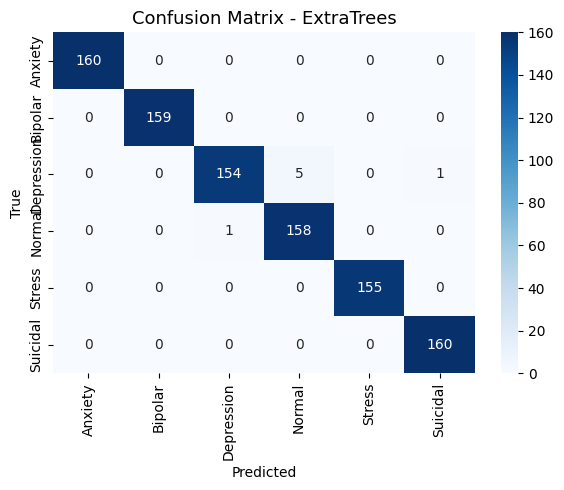


Step 15 complete: final evaluation done.


In [37]:
# ============================================================
# STEP 15: FINAL EVALUATION ON TEST SET
# ============================================================
# INPUT  : TUNED_MODELS, X_train_scaled, X_test_scaled, y_train, y_test
# OUTPUT : FINAL_MODEL (best), EVAL_RESULTS dict
# NOTE   : This is the ONLY time test set is used.
#          Train on full training set, evaluate on held-out test.
# ============================================================

try:
    print('=' * 60)
    print('STEP 15: FINAL EVALUATION ON TEST SET')
    print('=' * 60)

    if 'TUNED_MODELS' not in globals() or not TUNED_MODELS:
        raise ValueError(
            '[STEP 15 ERROR] TUNED_MODELS is empty. Step 14 must succeed or fall back before evaluation.'
        )

    print(f'  [INPUT] Tuned models: {list(TUNED_MODELS.keys())}')
    print(f'          X_train_scaled: {X_train_scaled.shape}')
    print(f'          X_test_scaled : {X_test_scaled.shape}')
    print('  NOTE: Test set used for the FIRST and ONLY time here.')
    print()

    EVAL_RESULTS = {}
    SAMPLE_WEIGHT_MODELS = {'XGBoost', 'LightGBM', 'HistGradBoost', 'RandomForest', 'ExtraTrees'}

    for model_name, model in TUNED_MODELS.items():
        print(f'  Evaluating {model_name}...')
        t0 = datetime.datetime.now()

        fit_kwargs = {}
        if IMBALANCE_STRATEGY == 'sample_weight' and SAMPLE_WEIGHTS_TRAIN is not None:
            if model_name in SAMPLE_WEIGHT_MODELS:
                fit_kwargs['sample_weight'] = SAMPLE_WEIGHTS_TRAIN

        model.fit(X_train_scaled, y_train, **fit_kwargs)
        elapsed_fit = (datetime.datetime.now() - t0).total_seconds()

        y_pred = model.predict(X_test_scaled)

        acc = accuracy_score(y_test, y_pred)
        balanced_acc = balanced_accuracy_score(y_test, y_pred)
        f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)
        f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
        prec_macro = precision_score(y_test, y_pred, average='macro', zero_division=0)
        rec_macro = recall_score(y_test, y_pred, average='macro', zero_division=0)
        prec_weighted = precision_score(y_test, y_pred, average='weighted', zero_division=0)
        rec_weighted = recall_score(y_test, y_pred, average='weighted', zero_division=0)
        cm = confusion_matrix(y_test, y_pred)
        report_dict = classification_report(
            y_test, y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        )

        EVAL_RESULTS[model_name] = {
            'accuracy': round(acc, 5),
            'balanced_accuracy': round(balanced_acc, 5),
            'f1_macro': round(f1_macro, 5),
            'f1_weighted': round(f1_weighted, 5),
            'precision_macro': round(prec_macro, 5),
            'recall_macro': round(rec_macro, 5),
            'precision_weighted': round(prec_weighted, 5),
            'recall_weighted': round(rec_weighted, 5),
            'fit_time_s': round(elapsed_fit, 2),
            'confusion_matrix': cm.tolist(),
            'classification_report': report_dict
        }

        print(f'    Accuracy         : {acc:.4f}')
        print(f'    Balanced Acc     : {balanced_acc:.4f}')
        print(f'    F1 Macro         : {f1_macro:.4f}')
        print(f'    F1 Weighted      : {f1_weighted:.4f}')
        print(f'    Precision Macro  : {prec_macro:.4f}')
        print(f'    Recall Macro     : {rec_macro:.4f}')
        print(f'    Train fit time   : {elapsed_fit:.1f}s')
        print()

    if not EVAL_RESULTS:
        raise ValueError(
            '[STEP 15 ERROR] No model evaluation results were produced. Check earlier steps.'
        )

    ranked_eval = sorted(
        EVAL_RESULTS.items(),
        key=lambda item: (item[1]['f1_macro'], item[1]['balanced_accuracy']),
        reverse=True
    )
    BEST_MODEL_NAME = ranked_eval[0][0]
    FINAL_MODEL = TUNED_MODELS[BEST_MODEL_NAME]

    print('=' * 60)
    print('  FINAL TEST LEADERBOARD')
    print('=' * 60)
    for rank, (name, metrics) in enumerate(ranked_eval, 1):
        print(
            f'  {rank}. {name:<20} F1 macro={metrics["f1_macro"]:.4f}  '
            f'Balanced Acc={metrics["balanced_accuracy"]:.4f}  Accuracy={metrics["accuracy"]:.4f}'
        )
    print('=' * 60)
    print(f'  WINNER: {BEST_MODEL_NAME}')
    print(f'  Test Accuracy      : {EVAL_RESULTS[BEST_MODEL_NAME]["accuracy"]:.4f}')
    print(f'  Balanced Accuracy  : {EVAL_RESULTS[BEST_MODEL_NAME]["balanced_accuracy"]:.4f}')
    print(f'  Test F1 Macro      : {EVAL_RESULTS[BEST_MODEL_NAME]["f1_macro"]:.4f}')
    print(f'  Test F1 Weighted   : {EVAL_RESULTS[BEST_MODEL_NAME]["f1_weighted"]:.4f}')
    print('=' * 60)
    print()

    y_pred_best = FINAL_MODEL.predict(X_test_scaled)
    print('  Per-class classification report:')
    print(classification_report(y_test, y_pred_best, target_names=class_names, zero_division=0))

    cm_best = confusion_matrix(y_test, y_pred_best)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes - 1)))
    sns.heatmap(
        cm_best, annot=True, fmt='d', cmap='Blues',
        xticklabels=class_names, yticklabels=class_names, ax=ax
    )
    ax.set_title(f'Confusion Matrix - {BEST_MODEL_NAME}', fontsize=13)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    plt.show()

    PIPELINE_STATE['final_evaluation'] = {
        'best_model': BEST_MODEL_NAME,
        'ranking': [
            {
                'model_name': name,
                'f1_macro': metrics['f1_macro'],
                'balanced_accuracy': metrics['balanced_accuracy'],
                'accuracy': metrics['accuracy']
            }
            for name, metrics in ranked_eval
        ],
        'results': EVAL_RESULTS
    }

    print('\nStep 15 complete: final evaluation done.')

except Exception as e:
    print(f'[STEP 15 ERROR] {type(e).__name__}: {e}')
    raise

In [38]:
# ============================================================
# STEP 16: SAVE ALL ARTIFACTS
# ============================================================
# INPUT  : FINAL_MODEL, scaler, label_encoder, outlier_transformers,
#          FEATURE_NAMES_SELECTED, PIPELINE_STATE, EVAL_RESULTS
# OUTPUT : Timestamped folder in voice_ml_pipeline_output/ with all files
#
# Files saved:
#   best_model.joblib           -- trained model
#   scaler.joblib               -- RobustScaler (fitted on train)
#   label_encoder.joblib        -- class index <-> class name
#   encoding_artifacts.joblib   -- compatibility placeholder for API contract
#   outlier_transformers.joblib -- per-column outlier params
#   feature_names.json          -- ordered list of selected features
#   model_metadata.json         -- metrics, best params, class names
#   pipeline_state.json         -- full run state (every step)
# ============================================================

try:
    print('=' * 60)
    print('STEP 16: SAVE ALL ARTIFACTS')
    print('=' * 60)

    if 'BEST_MODEL_NAME' not in globals() or BEST_MODEL_NAME not in EVAL_RESULTS:
        raise ValueError(
            '[STEP 16 ERROR] Final evaluation outputs are missing. Run Step 15 successfully first.'
        )

    created_at = datetime.datetime.now()
    timestamp = created_at.strftime('%d%m%Y_%H%M%S')
    run_dir = os.path.join(OUTPUT_DIR, f'{BEST_MODEL_NAME}_{timestamp}')
    os.makedirs(run_dir, exist_ok=True)
    print(f'  Output directory: {run_dir}')
    print()

    saved_files = []

    def _save(obj, filename, use_json=False):
        path = os.path.join(run_dir, filename)
        if use_json:
            with open(path, 'w') as f:
                json.dump(obj, f, indent=2, default=str)
        else:
            joblib.dump(obj, path, compress=3)
        size_kb = os.path.getsize(path) / 1024
        saved_files.append((filename, round(size_kb, 1)))
        print(f'  Saved: {filename:<40} ({size_kb:.1f} KB)')

    # This PCA-only pipeline has no categorical encoders, but the deployment
    # service expects the legacy artifact name to exist.
    encoding_artifacts = {
        'type': 'none',
        'columns': [],
        'reason': 'PCA-only numeric pipeline; no categorical encoding was applied.'
    }

    _save(FINAL_MODEL, 'best_model.joblib')
    _save(scaler, 'scaler.joblib')
    _save(label_encoder, 'label_encoder.joblib')
    _save(encoding_artifacts, 'encoding_artifacts.joblib')
    _save(outlier_transformers, 'outlier_transformers.joblib')
    _save(FEATURE_NAMES_SELECTED, 'feature_names.json', use_json=True)

    metadata = {
        'pipeline_version': 'voice-pca-pipeline-guided-v2',
        'created_at': created_at.isoformat(),
        'saved_at': created_at.strftime('%d-%m-%Y %H:%M:%S'),
        'task_type': 'classification',
        'target_column': TARGET_COLUMN,
        'best_model_name': BEST_MODEL_NAME,
        'best_model_params': BEST_PARAMS.get(BEST_MODEL_NAME, {}),
        'cv_score': PIPELINE_STATE.get('cv_training', {}).get('results', {}).get(BEST_MODEL_NAME, {}).get('mean_f1_macro'),
        'cv_scoring': PIPELINE_STATE.get('cv_training', {}).get('scoring', 'f1_macro'),
        'cv_summary': {
            'successful_models': PIPELINE_STATE.get('cv_training', {}).get('successful_models', []),
            'failed_models': PIPELINE_STATE.get('cv_training', {}).get('failed_models', {})
        },
        'test_metrics': EVAL_RESULTS[BEST_MODEL_NAME],
        'all_model_results': EVAL_RESULTS,
        'class_names': class_names,
        'n_classes': n_classes,
        'n_features': len(FEATURE_NAMES_SELECTED),
        'n_features_selected': len(FEATURE_NAMES_SELECTED),
        'feature_names': FEATURE_NAMES_SELECTED,
        'hardware': PIPELINE_STATE['config']['hardware'],
        'imbalance_strategy': IMBALANCE_STRATEGY
    }
    _save(metadata, 'model_metadata.json', use_json=True)

    PIPELINE_STATE['run_completed_at'] = created_at.isoformat()
    PIPELINE_STATE['artifact_save'] = {
        'output_dir': run_dir,
        'files': saved_files
    }
    _save(PIPELINE_STATE, 'pipeline_state.json', use_json=True)

    print()
    print('  All artifacts saved successfully.')
    print(f'  Total files: {len(saved_files)}')
    total_kb = sum(s for _, s in saved_files)
    print(f'  Total size : {total_kb:.1f} KB')
    print()
    print('  ============================================================')
    print('  PIPELINE COMPLETE')
    print(f'  Best model        : {BEST_MODEL_NAME}')
    print(f'  Accuracy          : {EVAL_RESULTS[BEST_MODEL_NAME]["accuracy"]:.4f}')
    print(f'  Balanced Accuracy : {EVAL_RESULTS[BEST_MODEL_NAME]["balanced_accuracy"]:.4f}')
    print(f'  F1 Macro          : {EVAL_RESULTS[BEST_MODEL_NAME]["f1_macro"]:.4f}')
    print(f'  F1 Weighted       : {EVAL_RESULTS[BEST_MODEL_NAME]["f1_weighted"]:.4f}')
    print(f'  Artifacts         : {run_dir}')
    print('  ============================================================')

    print('\nStep 16 complete: all artifacts saved.')

except Exception as e:
    print(f'[STEP 16 ERROR] {type(e).__name__}: {e}')
    raise

STEP 16: SAVE ALL ARTIFACTS
  Output directory: voice_ml_pipeline_output\ExtraTrees_25042026_142358

  Saved: best_model.joblib                        (11230.8 KB)
  Saved: scaler.joblib                            (0.6 KB)
  Saved: label_encoder.joblib                     (0.3 KB)
  Saved: encoding_artifacts.joblib                (0.1 KB)
  Saved: outlier_transformers.joblib              (0.7 KB)
  Saved: feature_names.json                       (0.1 KB)
  Saved: model_metadata.json                      (8.3 KB)
  Saved: pipeline_state.json                      (12.7 KB)

  All artifacts saved successfully.
  Total files: 8
  Total size : 11253.6 KB

  PIPELINE COMPLETE
  Best model        : ExtraTrees
  Accuracy          : 0.9927
  Balanced Accuracy : 0.9927
  F1 Macro          : 0.9927
  F1 Weighted       : 0.9926
  Artifacts         : voice_ml_pipeline_output\ExtraTrees_25042026_142358

Step 16 complete: all artifacts saved.
